In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
     

In [10]:
df= pd.read_csv("Polymer composite data.csv")
df.head()


,Composite_ID,Polymer_Matrix,Reinforcement_Type,Fiber_Length_mm,Fiber_Diameter_um,Fiber_Volume_Fraction_pct,Matrix_Density_g_cm3,Fiber_Density_g_cm3,Composite_Density_g_cm3,Void_Content_pct,...,Viscosity_Pa_s,Moisture_Content_pct,Crystallinity_pct,Glass_Transition_Temperature_C,Thermal_Conductivity_W_mK,Electrical_Conductivity_S_m,Elastic_Modulus_GPa,Hardness_HV,Application_Sector,Composite_Performance_Class
0,PC_00001,Polyimide,Hybrid Fiber,25.75,24.59,63.48,0.917,1.518,2.410,5.53,...,44.55,0.33,81.30,181.19,7.872,352069.025,93.40,258.61,Marine,Low
1,PC_00002,Polypropylene,Carbon Nanotube,89.29,13.52,58.27,1.583,2.769,1.027,2.77,...,122.79,4.07,67.92,137.69,2.297,58121.320,18.90,529.04,Construction,Moderate
2,PC_00003,Vinyl Ester,Hybrid Fiber,91.63,20.78,51.58,1.469,1.648,1.243,7.72,...,42.54,4.24,69.24,113.97,0.328,855095.264,117.45,87.37,Marine,Low
3,PC_00004,Polyethylene,Hybrid Fiber,43.05,18.12,39.46,1.213,2.029,2.465,0.28,...,80.90,4.82,22.00,239.02,2.222,90901.958,28.76,528.08,Aerospace,Moderate
4,PC_00005,Polyimide,Natural Fiber,66.34,7.34,70.66,1.544,2.079,1.399,1.37,...,84.30,4.75,63.62,157.01,4.465,367399.306,128.83,554.25,Biomedical,Excellent


In [5]:
df.tail()

,Composite_ID,Polymer_Matrix,Reinforcement_Type,Fiber_Length_mm,Fiber_Diameter_um,Fiber_Volume_Fraction_pct,Matrix_Density_g_cm3,Fiber_Density_g_cm3,Composite_Density_g_cm3,Void_Content_pct,...,Viscosity_Pa_s,Moisture_Content_pct,Crystallinity_pct,Glass_Transition_Temperature_C,Thermal_Conductivity_W_mK,Electrical_Conductivity_S_m,Elastic_Modulus_GPa,Hardness_HV,Application_Sector,Composite_Performance_Class
14995,PC_14996,Polyimide,Carbon Fiber,42.08,18.93,60.23,1.135,2.071,1.315,3.88,...,28.13,4.67,77.28,74.62,1.219,767518.753,98.15,238.26,Aerospace,Low
14996,PC_14997,Polyethylene,Hybrid Fiber,48.72,20.05,29.18,0.901,2.685,1.807,5.77,...,133.78,3.27,72.50,176.08,2.789,34990.915,95.88,487.81,Automotive,Moderate
14997,PC_14998,Polyester,Basalt Fiber,12.34,23.32,69.47,1.149,1.569,1.415,4.82,...,54.17,3.49,38.61,66.59,6.882,680057.085,188.37,437.17,Automotive,High
14998,PC_14999,Nylon,Graphene,12.44,19.23,40.44,1.112,2.789,1.787,1.32,...,90.95,4.39,38.07,103.13,10.262,836894.416,120.35,580.47,Sports,High
14999,PC_15000,Polyimide,Glass Fiber,96.48,12.04,45.94,0.970,1.346,2.498,7.99,...,148.88,3.32,24.93,257.73,8.363,2687.801,187.78,40.11,Aerospace,Low


In [7]:
df.shape

(15000, 34)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Composite_ID                    15000 non-null  str    
 1   Polymer_Matrix                  15000 non-null  str    
 2   Reinforcement_Type              15000 non-null  str    
 3   Fiber_Length_mm                 15000 non-null  float64
 4   Fiber_Diameter_um               15000 non-null  float64
 5   Fiber_Volume_Fraction_pct       15000 non-null  float64
 6   Matrix_Density_g_cm3            15000 non-null  float64
 7   Fiber_Density_g_cm3             15000 non-null  float64
 8   Composite_Density_g_cm3         15000 non-null  float64
 9   Void_Content_pct                15000 non-null  float64
 10  Porosity_pct                    15000 non-null  float64
 11  Layer_Count                     15000 non-null  int64  
 12  Fiber_Orientation_deg           15000 non-n

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
print(df.describe(include='all'))

       Composite_ID Polymer_Matrix Reinforcement_Type  Fiber_Length_mm  \
count         15000          15000              15000     15000.000000   
unique        15000             10                  8              NaN   
top        PC_00001            ABS      Natural Fiber              NaN   
freq              1           1559               1914              NaN   
mean            NaN            NaN                NaN        50.991487   
std             NaN            NaN                NaN        28.159373   
min             NaN            NaN                NaN         2.000000   
25%             NaN            NaN                NaN        26.690000   
50%             NaN            NaN                NaN        51.165000   
75%             NaN            NaN                NaN        75.030000   
max             NaN            NaN                NaN        99.990000   

        Fiber_Diameter_um  Fiber_Volume_Fraction_pct  Matrix_Density_g_cm3  \
count        15000.000000        

In [13]:
print(df.isnull().sum())

Composite_ID                         0
Polymer_Matrix                       0
Reinforcement_Type                   0
Fiber_Length_mm                      0
Fiber_Diameter_um                    0
Fiber_Volume_Fraction_pct            0
Matrix_Density_g_cm3                 0
Fiber_Density_g_cm3                  0
Composite_Density_g_cm3              0
Void_Content_pct                     0
Porosity_pct                         0
Layer_Count                          0
Fiber_Orientation_deg                0
Weave_Pattern                        0
Nanofiller_Content_pct               0
Particle_Size_nm                     0
Surface_Treatment                 3042
Manufacturing_Process                0
Processing_Temperature_C             0
Processing_Time_hr                   0
Pressure_MPa                         0
Cooling_Rate_C_min                   0
Mixing_Speed_rpm                     0
Mixing_Time_min                      0
Viscosity_Pa_s                       0
Moisture_Content_pct     

In [14]:
print(df.groupby('Polymer_Matrix').size())

Polymer_Matrix
ABS              1559
Epoxy            1530
Nylon            1511
PEEK             1476
Phenolic         1471
Polyester        1475
Polyethylene     1487
Polyimide        1525
Polypropylene    1494
Vinyl Ester      1472
dtype: int64


In [15]:
print(df.groupby('Composite_Performance_Class').size())

Composite_Performance_Class
Excellent     161
High         2820
Low          5439
Moderate     6580
dtype: int64


In [16]:
print(df.groupby('Application_Sector').size())

Application_Sector
Aerospace       2111
Automotive      2084
Biomedical      2102
Construction    2186
Electronics     2151
Marine          2198
Sports          2168
dtype: int64


In [6]:
print(df.groupby('Reinforcement_Type').size())

Reinforcement_Type
Basalt Fiber       1870
Carbon Fiber       1886
Carbon Nanotube    1874
Glass Fiber        1907
Graphene           1836
Hybrid Fiber       1881
Kevlar             1832
Natural Fiber      1914
dtype: int64


In [32]:
df['Composite_Performance_Class'] = df['Composite_Performance_Class'].map({'Low': 0, 'Moderate': 1, 'High': 2, 'Excellent': 3})

In [39]:
df.head()

,Composite_ID,Polymer_Matrix,Reinforcement_Type,Fiber_Length_mm,Fiber_Diameter_um,Fiber_Volume_Fraction_pct,Matrix_Density_g_cm3,Fiber_Density_g_cm3,Composite_Density_g_cm3,Void_Content_pct,...,Viscosity_Pa_s,Moisture_Content_pct,Crystallinity_pct,Glass_Transition_Temperature_C,Thermal_Conductivity_W_mK,Electrical_Conductivity_S_m,Elastic_Modulus_GPa,Hardness_HV,Application_Sector,Composite_Performance_Class
0,PC_00001,Polyimide,Hybrid Fiber,25.75,24.59,63.48,0.917,1.518,2.410,5.53,...,44.55,0.33,81.30,181.19,7.872,352069.025,93.40,258.61,Marine,0
1,PC_00002,Polypropylene,Carbon Nanotube,89.29,13.52,58.27,1.583,2.769,1.027,2.77,...,122.79,4.07,67.92,137.69,2.297,58121.320,18.90,529.04,Construction,1
2,PC_00003,Vinyl Ester,Hybrid Fiber,91.63,20.78,51.58,1.469,1.648,1.243,7.72,...,42.54,4.24,69.24,113.97,0.328,855095.264,117.45,87.37,Marine,0
3,PC_00004,Polyethylene,Hybrid Fiber,43.05,18.12,39.46,1.213,2.029,2.465,0.28,...,80.90,4.82,22.00,239.02,2.222,90901.958,28.76,528.08,Aerospace,1
4,PC_00005,Polyimide,Natural Fiber,66.34,7.34,70.66,1.544,2.079,1.399,1.37,...,84.30,4.75,63.62,157.01,4.465,367399.306,128.83,554.25,Biomedical,3


Heatmap saved as correlation_heatmap.png


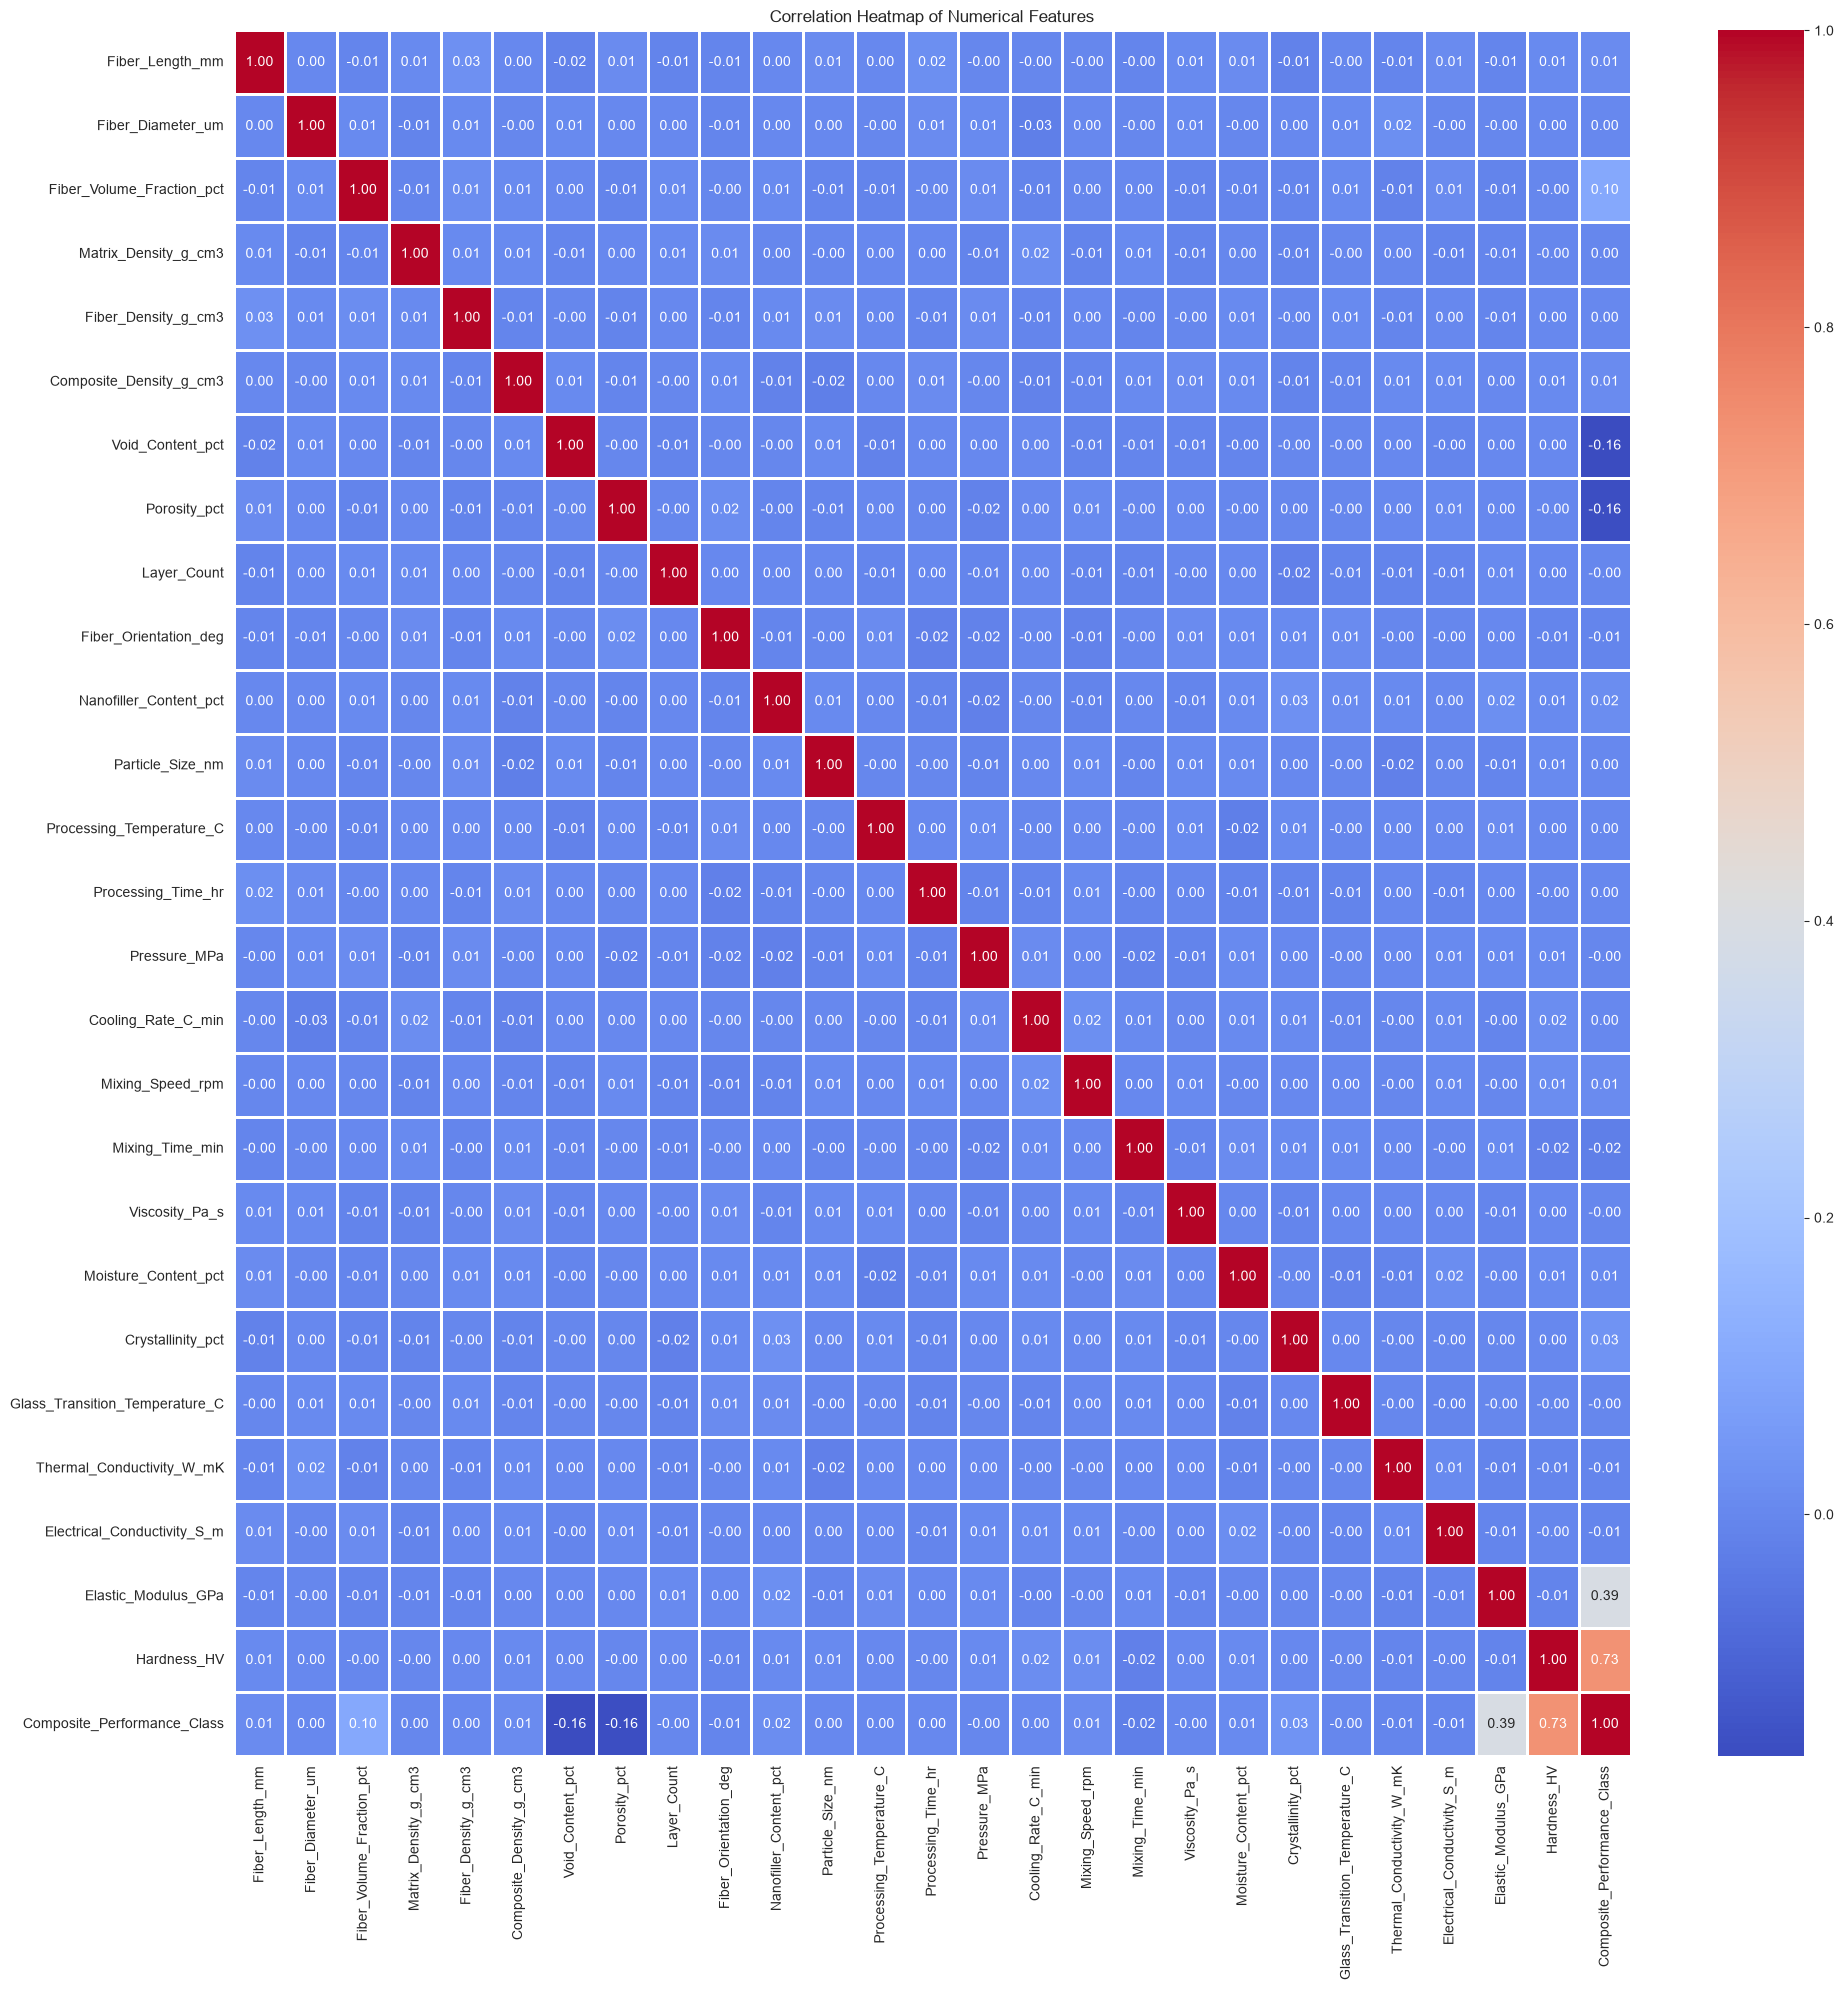

In [41]:
numerical_dataset = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 20))
sns.heatmap(numerical_dataset.corr(),
            cmap='coolwarm',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

In [42]:
from scipy import stats

In [43]:
z=np.abs(stats.zscore(numerical_dataset))
print(z)

[[0.89640947 1.6642793  1.00422177 ... 0.44159211 0.31203963 1.12162014]
 [1.36010802 0.24816541 0.67535115 ... 1.47861616 1.30640418 0.2028152 ]
 [1.44320923 1.00606662 0.25305856 ... 0.10682126 1.33686054 1.12162014]
 ...
 [1.37264333 1.44487507 1.3823283  ... 0.88036995 0.75658932 1.52725053]
 [1.36909199 0.73828981 0.45013121 ... 0.06645388 1.61419756 1.52725053]
 [1.61544892 0.50384908 0.10295494 ... 0.87215728 1.61969771 1.12162014]]


In [44]:
new_data=numerical_dataset[(z<3).all(axis=1)]

In [45]:
new_data.shape

(15000, 27)

In [37]:
df.shape

(15000, 34)

In [54]:
from sklearn.model_selection import train_test_split
x=new_data.drop(columns=['Composite_Performance_Class'])
y=new_data['Composite_Performance_Class']

In [57]:
x.head()


,Fiber_Length_mm,Fiber_Diameter_um,Fiber_Volume_Fraction_pct,Matrix_Density_g_cm3,Fiber_Density_g_cm3,Composite_Density_g_cm3,Void_Content_pct,Porosity_pct,Layer_Count,Fiber_Orientation_deg,...,Mixing_Speed_rpm,Mixing_Time_min,Viscosity_Pa_s,Moisture_Content_pct,Crystallinity_pct,Glass_Transition_Temperature_C,Thermal_Conductivity_W_mK,Electrical_Conductivity_S_m,Elastic_Modulus_GPa,Hardness_HV
0,25.75,24.59,63.48,0.917,1.518,2.410,5.53,7.72,16,30,...,1523,11,44.55,0.33,81.30,181.19,7.872,352069.025,93.40,258.61
1,89.29,13.52,58.27,1.583,2.769,1.027,2.77,6.66,2,45,...,488,33,122.79,4.07,67.92,137.69,2.297,58121.320,18.90,529.04
2,91.63,20.78,51.58,1.469,1.648,1.243,7.72,8.31,2,15,...,1527,99,42.54,4.24,69.24,113.97,0.328,855095.264,117.45,87.37
3,43.05,18.12,39.46,1.213,2.029,2.465,0.28,9.28,15,15,...,702,90,80.90,4.82,22.00,239.02,2.222,90901.958,28.76,528.08
4,66.34,7.34,70.66,1.544,2.079,1.399,1.37,5.78,6,0,...,2260,56,84.30,4.75,63.62,157.01,4.465,367399.306,128.83,554.25


In [78]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
                

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
rf_classificationModel=RandomForestClassifier(n_estimators=100, random_state=0)

In [96]:
rf_classificationModel.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [97]:
y_pred=rf_classificationModel.predict(x_test)

In [98]:
y_pred

array([1, 0, 1, ..., 0, 2, 1], shape=(3000,))

In [99]:
from sklearn import metrics
print('accuracy_score',metrics.accuracy_score(y_test, y_pred))

accuracy_score 0.8196666666666667


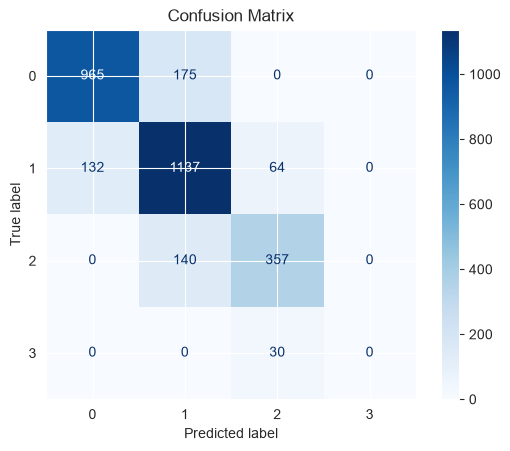

<Figure size 640x480 with 0 Axes>

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
plt.savefig("Confusion Matrix.png")


In [101]:
print(metrics.classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1140
           1       0.78      0.85      0.82      1333
           2       0.79      0.72      0.75       497
           3       0.00      0.00      0.00        30

    accuracy                           0.82      3000
   macro avg       0.61      0.60      0.61      3000
weighted avg       0.81      0.82      0.82      3000



C:\Users\dinet\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dinet\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dinet\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
